# Explainable Customer Churn Prediction

## 1. Data Understanding

This notebook focuses on understanding the customer churn dataset,
including its structure, features, data types, missing values,
and target variable distribution.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df['Churn'].value_counts(normalize='index')*100

,proportion
Churn,
No,73.463013
Yes,26.536987


## Key Observations

- The dataset contains 7,043 customer records and 21 columns.
- `Churn` is the target variable for binary classification.
- `customerID` is an identifier and is not expected to provide predictive value.
- The dataset contains both numerical and categorical features.
- `TotalCharges` is expected to be numerical but is currently stored as an object.
- The target variable is imbalanced, with approximately 73.5% non-churned and 26.5% churned customers.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['TotalCharges'].value_counts().tail()

,count
TotalCharges,
130.15,1
3211.9,1
7843.55,1
2196.3,1
197.4,1


In [ ]:
df['TotalCharges'].str.strip().eq("").sum()

np.int64(11)

In [ ]:
df[df['TotalCharges'].str.strip()==""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [ ]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df['customerID'].nunique()

7043

In [ ]:
df.drop('customerID',axis=1,inplace=True)

In [ ]:
df.shape

(7043, 20)

## 2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand
the distribution of variables, identify patterns, and investigate
relationships between customer characteristics and churn.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

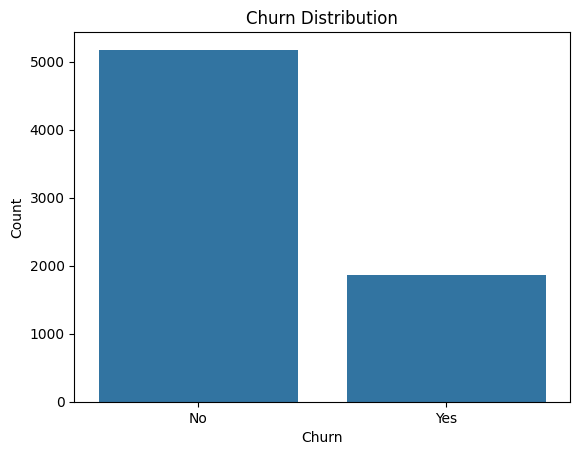

In [ ]:
sns.countplot(data=df,x='Churn')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [ ]:
churn = df['Churn'].value_counts(normalize=True) * 100
churn

,proportion
Churn,
No,73.463013
Yes,26.536987


In [ ]:
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


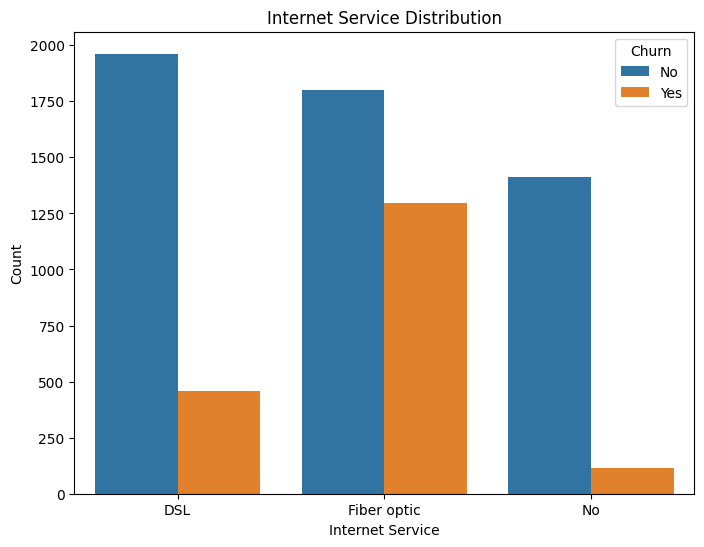

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='InternetService', hue="Churn")
plt.title('Internet Service Distribution')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()

In [ ]:
Internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### Churn by Internet Service

- Internet service type shows differences in customer churn rates.
- Fiber optic customers have the highest churn rate among the three groups.
- Customers without internet service have the lowest churn rate.
- This suggests that `InternetService` may be an important feature for predicting customer churn.
- However, this relationship does not mean that internet service type directly causes churn.

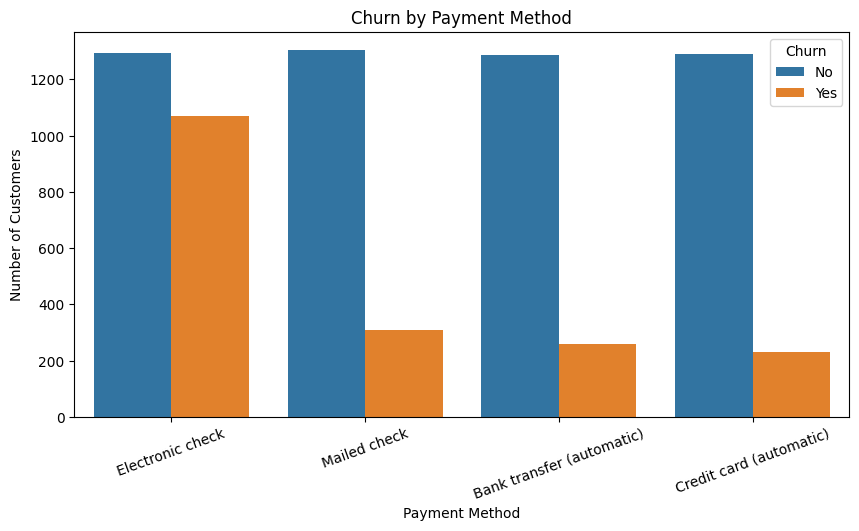

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

In [ ]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100
payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


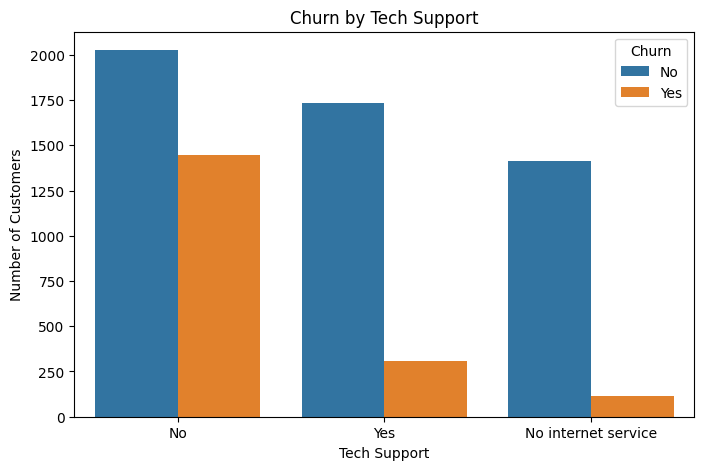

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="TechSupport", hue="Churn")

plt.title("Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
techsupport_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100
techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


### Churn by Tech Support

- Tech support status shows a noticeable relationship with customer churn.
- Customers without technical support have a higher churn rate than customers with technical support.
- Customers with no internet service have the lowest churn rate.
- `TechSupport` may be an important feature for predicting customer churn.
- The relationship represents an association and does not establish causation.

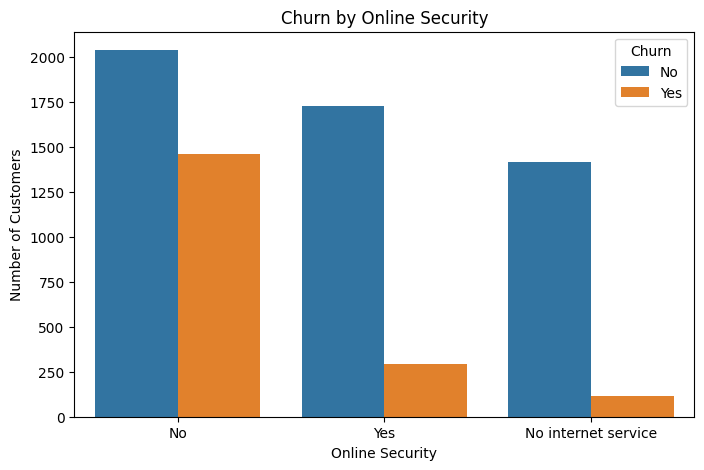

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="OnlineSecurity", hue="Churn")

plt.title("Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


### Churn by Online Security

- Online security status shows a noticeable relationship with customer churn.
- Customers without online security have a higher churn rate than customers with online security.
- Customers with no internet service have the lowest churn rate.
- `OnlineSecurity` may be useful for predicting customer churn.
- This relationship represents an association and does not establish causation.

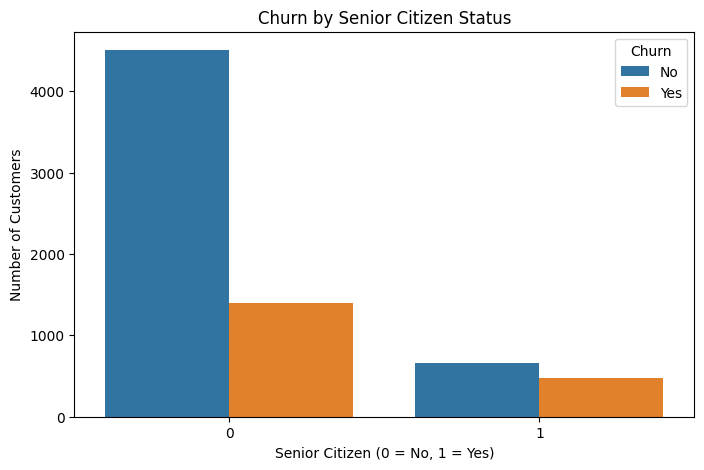

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="SeniorCitizen", hue="Churn")

plt.title("Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn


Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


### Churn by Senior Citizen Status

- Senior citizen status shows a noticeable relationship with customer churn.
- Senior citizens have a higher churn rate than non-senior customers.
- `SeniorCitizen` may therefore be a useful feature for predicting customer churn.
- This relationship represents an association and does not establish causation.

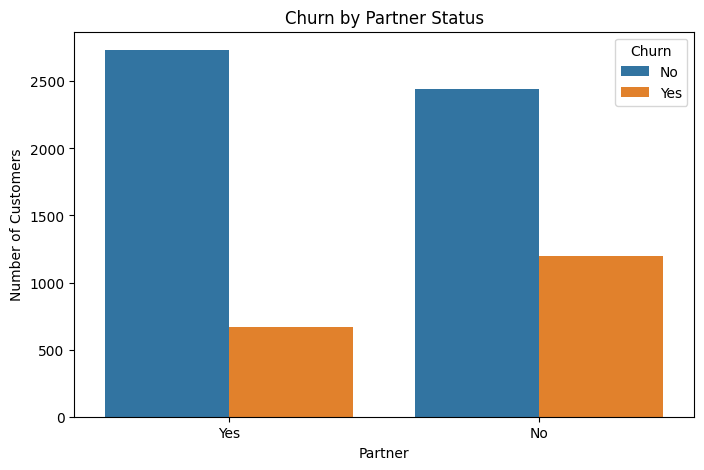

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Partner", hue="Churn")

plt.title("Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

partner_churn

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


### Churn by Partner Status

- Partner status shows a relationship with customer churn.
- Customers without a partner have a higher churn rate than customers with a partner.
- `Partner` may therefore be a useful feature for predicting customer churn.
- This relationship represents an association and does not establish causation.

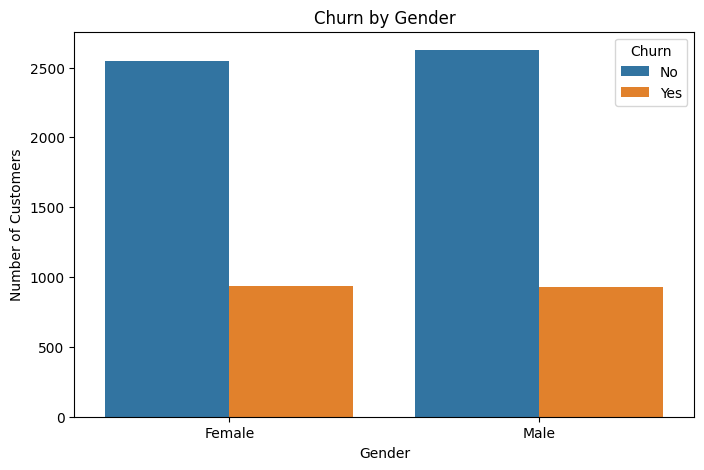

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="gender", hue="Churn")

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

gender_churn

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


### Churn by Gender

- The churn rates for male and female customers are very similar.
- Gender does not appear to have a strong relationship with customer churn in this dataset.
- `gender` may therefore provide limited predictive information compared with features such as contract type, tenure, and payment method.
- The analysis shows an association in the dataset and does not establish causation.

In [ ]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


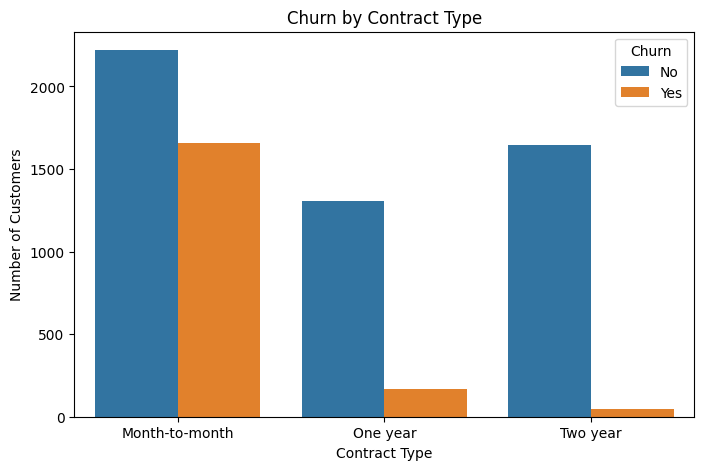

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

### Churn by Contract Type

- Contract type shows a strong relationship with customer churn.
- Month-to-month customers have the highest churn rate.
- Customers with one-year contracts have a much lower churn rate.
- Customers with two-year contracts have the lowest churn rate.
- This suggests that customers with longer-term contracts are less likely to churn.
- `Contract` may therefore be an important feature for predicting customer churn.
- This relationship represents an association and does not establish causation.

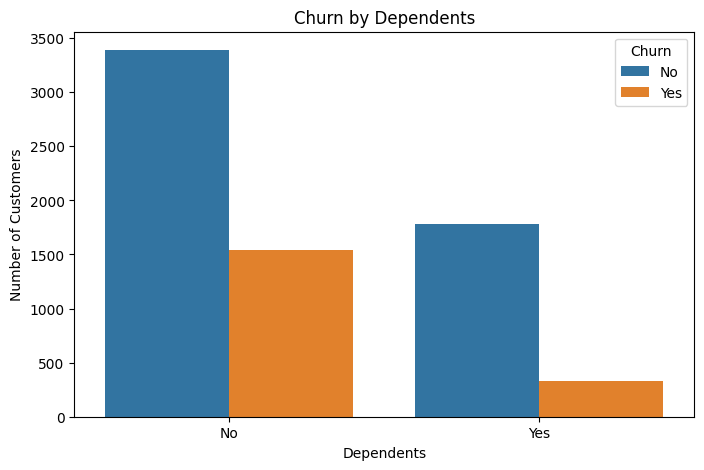

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Dependents", hue="Churn")

plt.title("Churn by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

dependents_churn

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


### Churn by Dependents

- Dependents status shows a noticeable relationship with customer churn.
- Customers without dependents have a higher churn rate than customers with dependents.
- Customers with dependents have a comparatively lower churn rate.
- `Dependents` may therefore provide useful information for predicting customer churn.
- This relationship represents an association and does not establish causation.

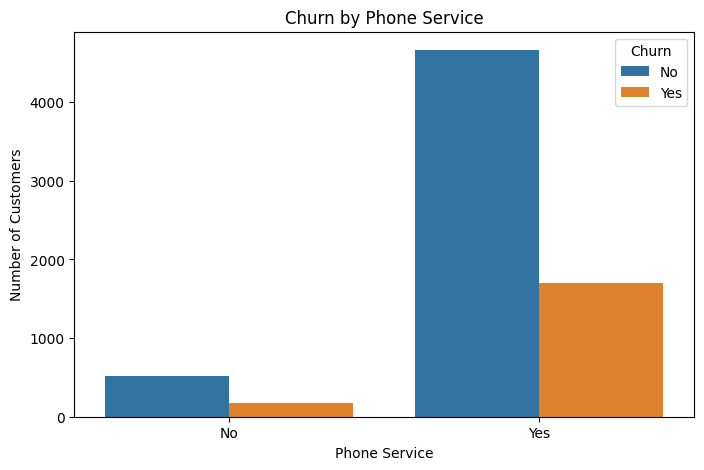

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='PhoneService',hue='Churn')
plt.title('Churn by Phone Service')
plt.xlabel('Phone Service')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
phone_churn = pd.crosstab(
    df["PhoneService"],
    df["Churn"],
    normalize="index"
) * 100

phone_churn

Churn,No,Yes
PhoneService,,
No,75.073314,24.926686
Yes,73.290363,26.709637


### Churn by Phone Service

- Phone service status shows a relatively weak relationship with customer churn.
- The churn rates between customers with and without phone service are comparatively similar.
- `PhoneService` may provide limited predictive information compared with stronger features such as `Contract` and `Tenure`.
- This relationship represents an association and does not establish causation.

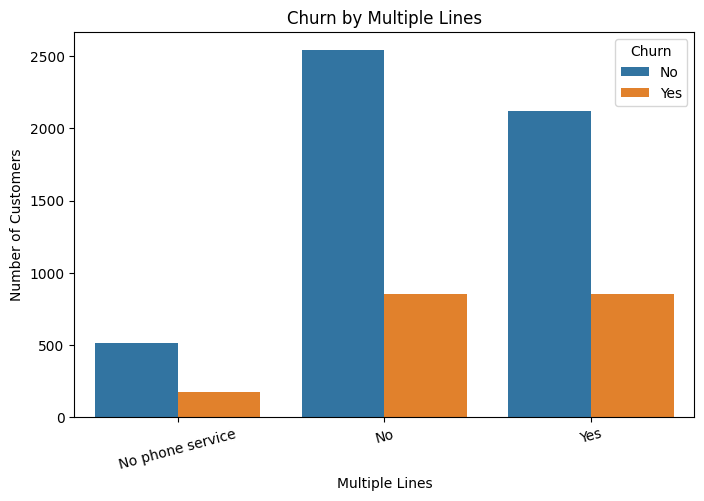

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="MultipleLines", hue="Churn")

plt.title("Churn by Multiple Lines")
plt.xlabel("Multiple Lines")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

In [ ]:
multiplelines_churn = pd.crosstab(
    df["MultipleLines"],
    df["Churn"],
    normalize="index"
) * 100

multiplelines_churn

Churn,No,Yes
MultipleLines,,
No,74.955752,25.044248
No phone service,75.073314,24.926686
Yes,71.390104,28.609896


### Churn by Multiple Lines

- Multiple lines status does not show a very strong relationship with customer churn.
- Customers with and without multiple lines have relatively similar churn patterns.
- Customers with no phone service form a separate group and show a different churn pattern.
- `MultipleLines` may provide some information for prediction, but it appears less influential than features such as `Contract`, `Tenure`, and `MonthlyCharges`.
- This relationship represents an association and does not establish causation.

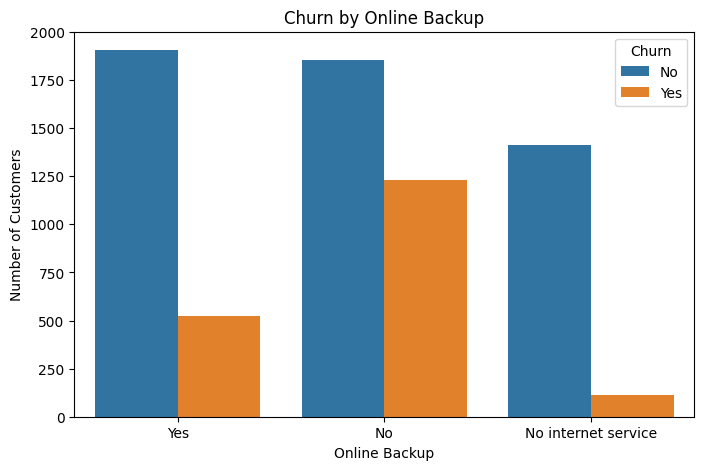

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="OnlineBackup", hue="Churn")

plt.title("Churn by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
onlinebackup_churn = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

onlinebackup_churn

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


### Churn by Online Backup

- Online backup status shows a noticeable relationship with customer churn.
- Customers without online backup have a higher churn rate than customers with online backup.
- Customers with no internet service have a comparatively low churn rate.
- `OnlineBackup` may provide useful information for predicting customer churn.
- This relationship represents an association and does not establish causation.

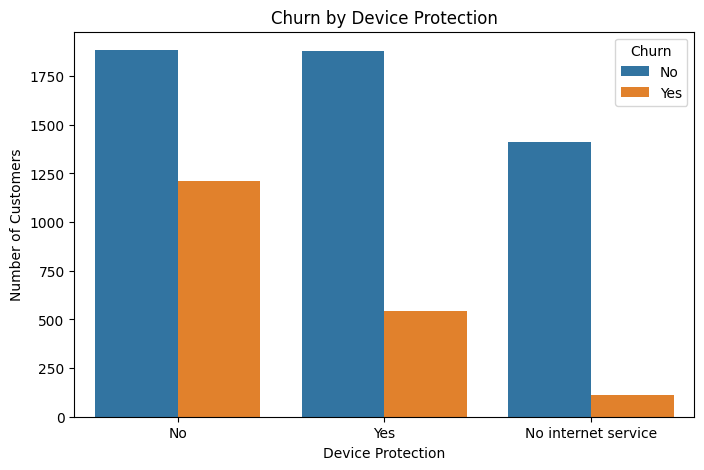

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="DeviceProtection", hue="Churn")

plt.title("Churn by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
device_churn = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

device_churn

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


### Churn by Device Protection

- Device protection status shows a noticeable relationship with customer churn.
- Customers without device protection have a higher churn rate than customers with device protection.
- Customers with no internet service have a comparatively low churn rate.
- `DeviceProtection` may provide useful information for predicting customer churn.
- This relationship represents an association and does not establish causation.

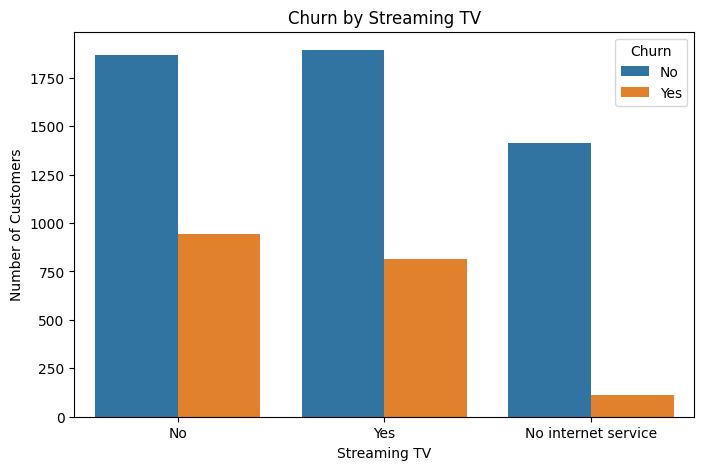

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="StreamingTV", hue="Churn")

plt.title("Churn by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
streamingtv_churn = pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

streamingtv_churn

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


### Churn by Streaming TV

- Streaming TV status does not show a very strong relationship with customer churn.
- Customers with and without Streaming TV have relatively similar churn patterns.
- Customers with no internet service have a comparatively low churn rate.
- `StreamingTV` may provide some information for prediction, but it appears less influential than features such as `Contract`, `Tenure`, and `MonthlyCharges`.
- This relationship represents an association and does not establish causation.

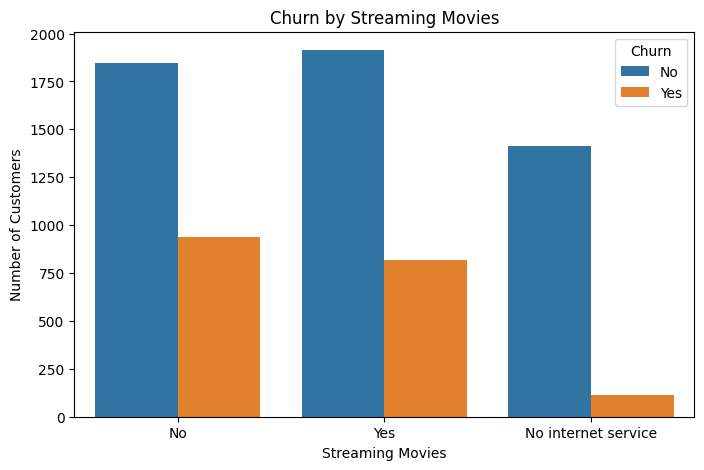

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="StreamingMovies", hue="Churn")

plt.title("Churn by Streaming Movies")
plt.xlabel("Streaming Movies")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
streamingmovies_churn = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

streamingmovies_churn

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


### Churn by Streaming Movies

- Streaming Movies status does not show a very strong relationship with customer churn.
- Customers with and without Streaming Movies have relatively similar churn patterns.
- Customers with no internet service have a comparatively low churn rate.
- `StreamingMovies` may provide some information for prediction, but it appears less influential than features such as `Contract`, `Tenure`, and `MonthlyCharges`.
- This relationship represents an association and does not establish causation.

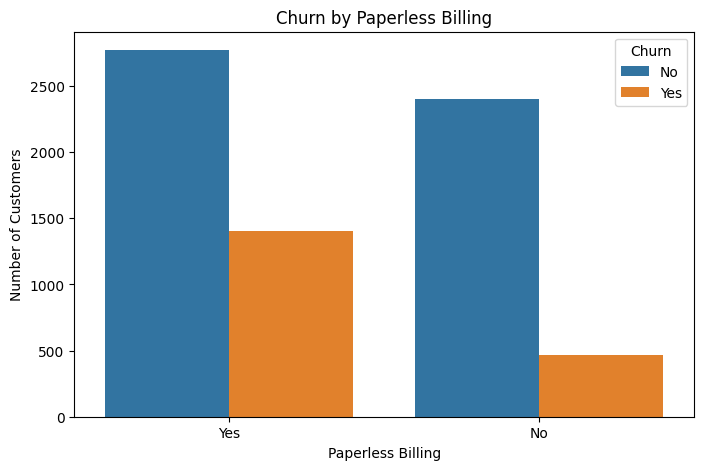

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="PaperlessBilling", hue="Churn")

plt.title("Churn by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
paperless_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

paperless_churn

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


### Churn by Paperless Billing

- Paperless billing status shows a noticeable relationship with customer churn.
- Customers using paperless billing have a higher churn rate than customers who do not use paperless billing.
- `PaperlessBilling` may therefore provide useful information for predicting customer churn.
- This relationship represents an association and does not establish causation.

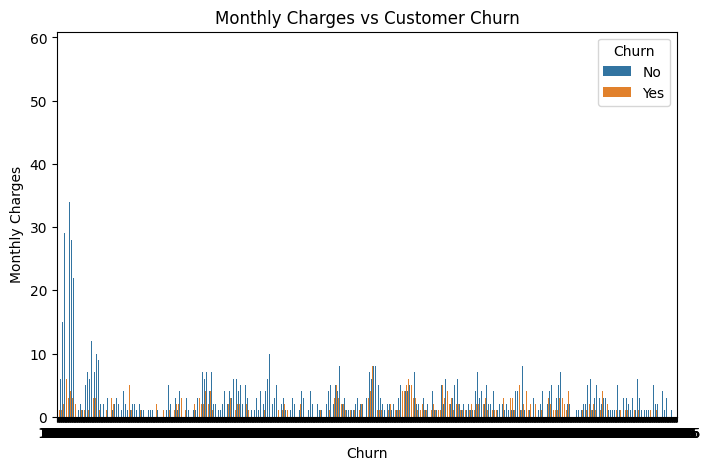

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, hue="Churn", x="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [ ]:
df['MonthlyCharges'].value_counts()

,count
MonthlyCharges,
20.05,61
19.85,45
19.95,44
19.90,44
20.00,43
...,...
56.85,1
101.70,1
48.40,1


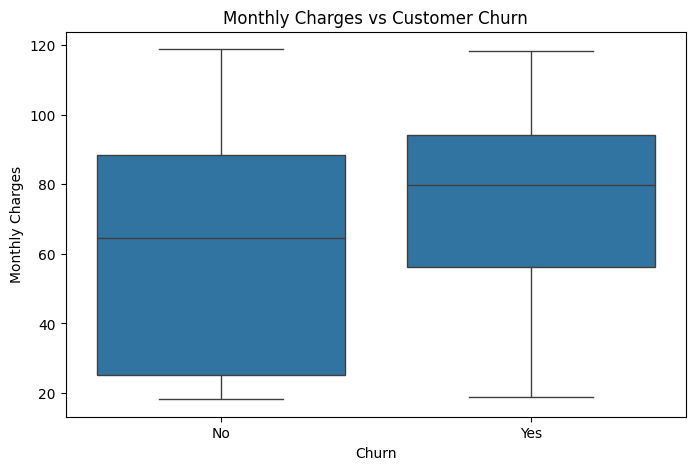

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


### Monthly Charges vs Customer Churn

- Customers who churn generally have higher monthly charges than customers who stay.
- The boxplot shows a difference in the distribution of monthly charges between the two churn groups.
- The average monthly charge is also higher among churned customers.
- `MonthlyCharges` may therefore be an important feature for predicting customer churn.
- This relationship represents an association and does not establish causation.

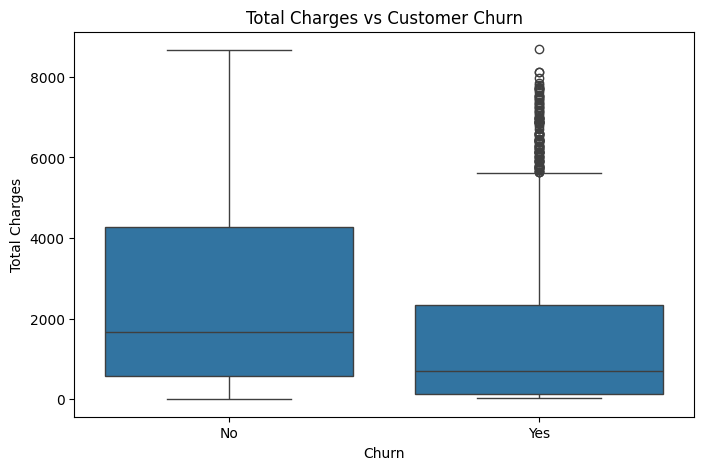

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="TotalCharges")

plt.title("Total Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

In [ ]:
df.groupby("Churn")["TotalCharges"].mean()

,TotalCharges
Churn,
No,2549.911442
Yes,1531.796094


### Total Charges vs Customer Churn

- Total charges show a noticeable difference between customers who stayed and customers who churned.
- Churned customers generally have lower total charges than customers who stayed.
- This is partly related to customer tenure, since customers who have stayed longer have had more time to accumulate total charges.
- `TotalCharges` may provide useful information for predicting customer churn.
- The relationship represents an association and does not establish causation.

In [ ]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


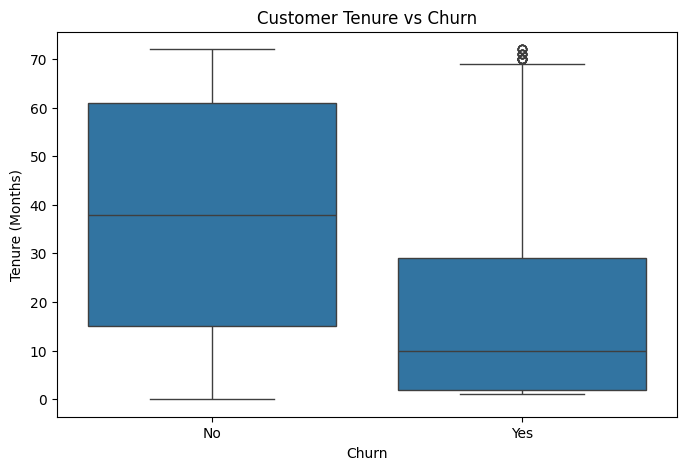

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

### Customer Tenure vs Churn

- Customer tenure shows a strong relationship with churn.
- Churned customers generally have shorter tenure than customers who stay.
- Customers who have been with the company for a longer period tend to be less likely to churn.
- `tenure` may therefore be an important feature for predicting customer churn.
- This relationship represents an association and does not establish causation.

In [ ]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


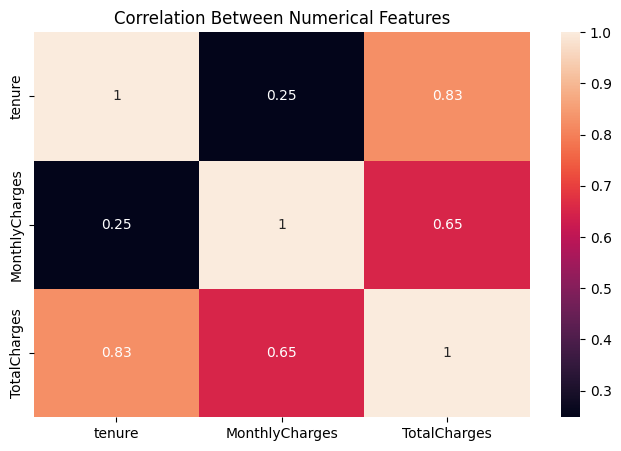

In [ ]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True
)

plt.title("Correlation Between Numerical Features")
plt.show()

In [ ]:
df['tenure'].value_counts()

,count
tenure,
1,613
72,362
2,238
3,200
4,176
...,...
28,57
39,56
44,51


### Correlation Between Numerical Features

- Correlation analysis was performed to understand relationships among the numerical features.
- `tenure` and `TotalCharges` show a strong positive correlation.
- This relationship is intuitive because customers who stay longer generally accumulate higher total charges.
- `MonthlyCharges` also shows a positive relationship with `TotalCharges`.
- Correlation measures association between numerical variables and does not imply causation.

## 3. EDA Summary

The exploratory data analysis revealed several important patterns related to customer churn.

### Key Findings

- The dataset contains approximately 26.5% churned customers and 73.5% customers who stayed, indicating an imbalanced target variable.
- Customer tenure has a strong relationship with churn. Customers with shorter tenure are more likely to churn.
- Monthly charges are generally higher among customers who churn.
- Contract type is strongly associated with churn. Month-to-month customers have a much higher churn rate than customers with one-year or two-year contracts.
- Fiber optic customers show a higher churn rate compared with DSL and customers without internet service.
- Customers using electronic checks have a noticeably higher churn rate than customers using other payment methods.
- Customers without technical support and online security generally have higher churn rates.
- Senior citizens have a higher churn rate compared with non-senior customers.
- Customers without partners or dependents generally show higher churn rates.
- Gender shows relatively little difference in churn rates between male and female customers.
- Some service-related variables, such as Streaming TV and Multiple Lines, show weaker relationships with churn.
- `tenure` and `TotalCharges` have a strong positive correlation because customers who stay longer generally accumulate higher total charges.

### Overall EDA Insight

The analysis suggests that customer churn is associated with several factors, particularly contract type, tenure, monthly charges, payment method, and certain subscribed services.

These findings will help guide feature engineering and model development in the next stages of the project.

EDA findings represent associations in the dataset and do not establish causal relationships.